In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
import seaborn as sns

In [2]:
df = pd.read_csv("loan_approval_dataset.csv")

In [3]:
df.head()
#df.info
#print(df[" loan_status"])

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [5]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

# handle missing values

In [6]:
numerical_col = df.select_dtypes(include = ["number"]).columns
caterocial_col = df.select_dtypes(include = ["object"]).columns

In [7]:
from sklearn.impute import SimpleImputer
num_col = SimpleImputer(strategy = "mean")
df[numerical_col] = num_col.fit_transform(df[numerical_col])



In [8]:
col_col = SimpleImputer(strategy = "most_frequent")
df[caterocial_col] = col_col.fit_transform(df[caterocial_col])

In [9]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

# EDA


Text(0.5, 1.0, 'percentage of loan approve')

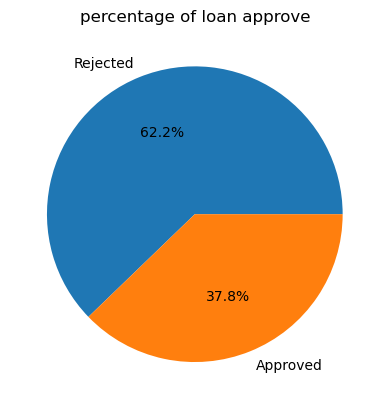

In [10]:
counted_values = df[" loan_status"].value_counts()
plt.pie(counted_values, labels = ["Rejected", "Approved"], autopct = "%1.1f%%")
plt.title("percentage of loan approve")


[Text(0, 0, '2144'), Text(0, 0, '2125')]

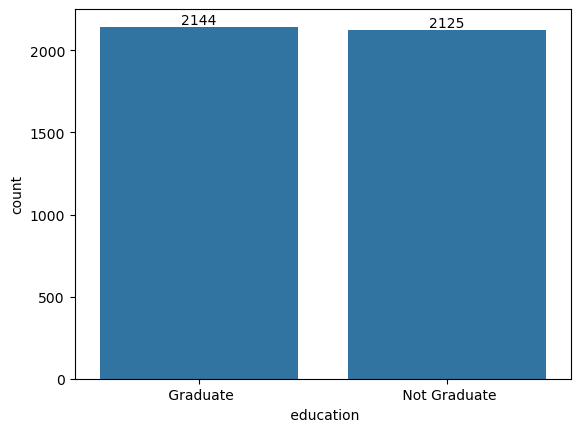

In [11]:
edu_count = df[" education"].value_counts()
ax = sns.barplot(edu_count)
ax.bar_label(ax.containers[0])

<Axes: xlabel=' income_annum', ylabel='Count'>

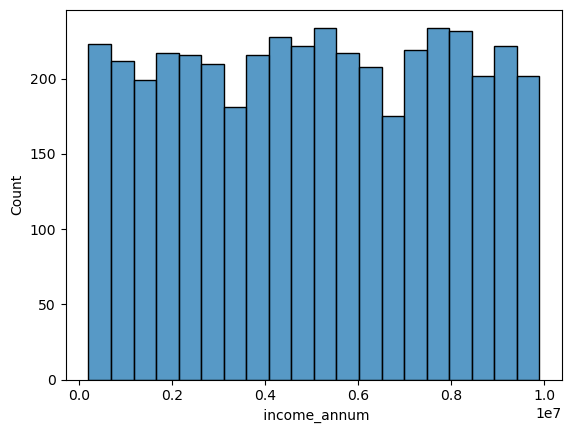

In [12]:
sns.histplot(
    data = df,
    x = " income_annum",
    bins = 20
)

## outliers

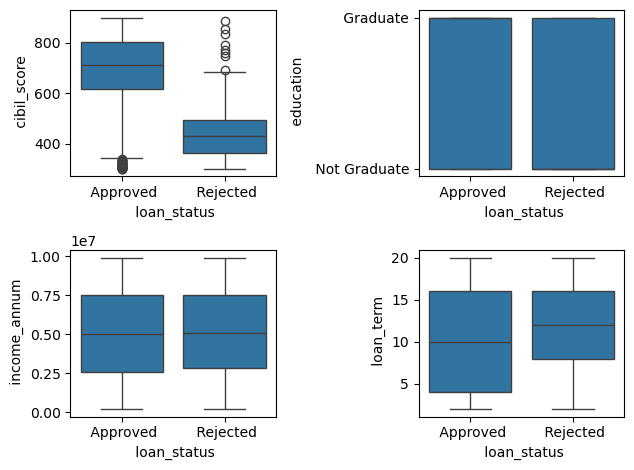

In [13]:
fig, axis = plt.subplots(2,2)
sns.boxplot(ax = axis[0,0],data = df,x = " loan_status", y = " cibil_score")
sns.boxplot(ax = axis[0,1],data = df,x = " loan_status", y = " education")
sns.boxplot(ax = axis[1,0],data = df,x = " loan_status", y = " income_annum")
sns.boxplot(ax = axis[1,1],data = df,x = " loan_status", y = " loan_term")

plt.tight_layout()

<Axes: xlabel=' cibil_score', ylabel='Count'>

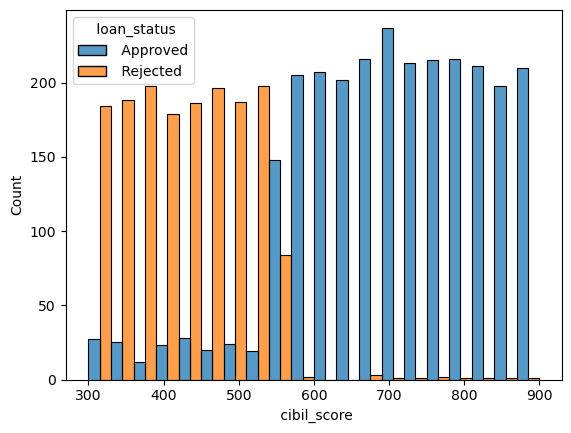

In [14]:
sns.histplot(
    data = df,
    x = ' cibil_score',
    hue = " loan_status",
    bins = 20,
    multiple = "dodge"
)

In [15]:
df = df.drop("loan_id", axis = 1)
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2.0,Graduate,No,9600000.0,29900000.0,12.0,778.0,2400000.0,17600000.0,22700000.0,8000000.0,Approved
1,0.0,Not Graduate,Yes,4100000.0,12200000.0,8.0,417.0,2700000.0,2200000.0,8800000.0,3300000.0,Rejected
2,3.0,Graduate,No,9100000.0,29700000.0,20.0,506.0,7100000.0,4500000.0,33300000.0,12800000.0,Rejected
3,3.0,Graduate,No,8200000.0,30700000.0,8.0,467.0,18200000.0,3300000.0,23300000.0,7900000.0,Rejected
4,5.0,Not Graduate,Yes,9800000.0,24200000.0,20.0,382.0,12400000.0,8200000.0,29400000.0,5000000.0,Rejected


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0    no_of_dependents          4269 non-null   float64
 1    education                 4269 non-null   object 
 2    self_employed             4269 non-null   object 
 3    income_annum              4269 non-null   float64
 4    loan_amount               4269 non-null   float64
 5    loan_term                 4269 non-null   float64
 6    cibil_score               4269 non-null   float64
 7    residential_assets_value  4269 non-null   float64
 8    commercial_assets_value   4269 non-null   float64
 9    luxury_assets_value       4269 non-null   float64
 10   bank_asset_value          4269 non-null   float64
 11   loan_status               4269 non-null   object 
dtypes: float64(9), object(3)
memory usage: 400.3+ KB


## encoding

In [17]:
lc = LabelEncoder()
df[" education"] = lc.fit_transform(df[" education"])
df[" loan_status"] = lc.fit_transform(df[" loan_status"])

In [18]:
ohe = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore")
cols = [" self_employed"]
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols), index = df.index)
df = pd.concat([df.drop(columns = cols),encoded_df], axis = 1)

In [28]:
## corelation heatmap

num_col = df.select_dtypes(include = "number")
corr_matrix = num_col.corr()
num_col.corr()[" loan_status"].sort_values(ascending = False)

loan_status                 1.000000
loan_term                   0.113036
no_of_dependents            0.018114
luxury_assets_value         0.015465
income_annum                0.015189
residential_assets_value    0.014367
bank_asset_value            0.006778
education                   0.004918
self_employed_ Yes         -0.000345
commercial_assets_value    -0.008246
loan_amount                -0.016150
cibil_score                -0.770518
Name:  loan_status, dtype: float64

<Axes: >

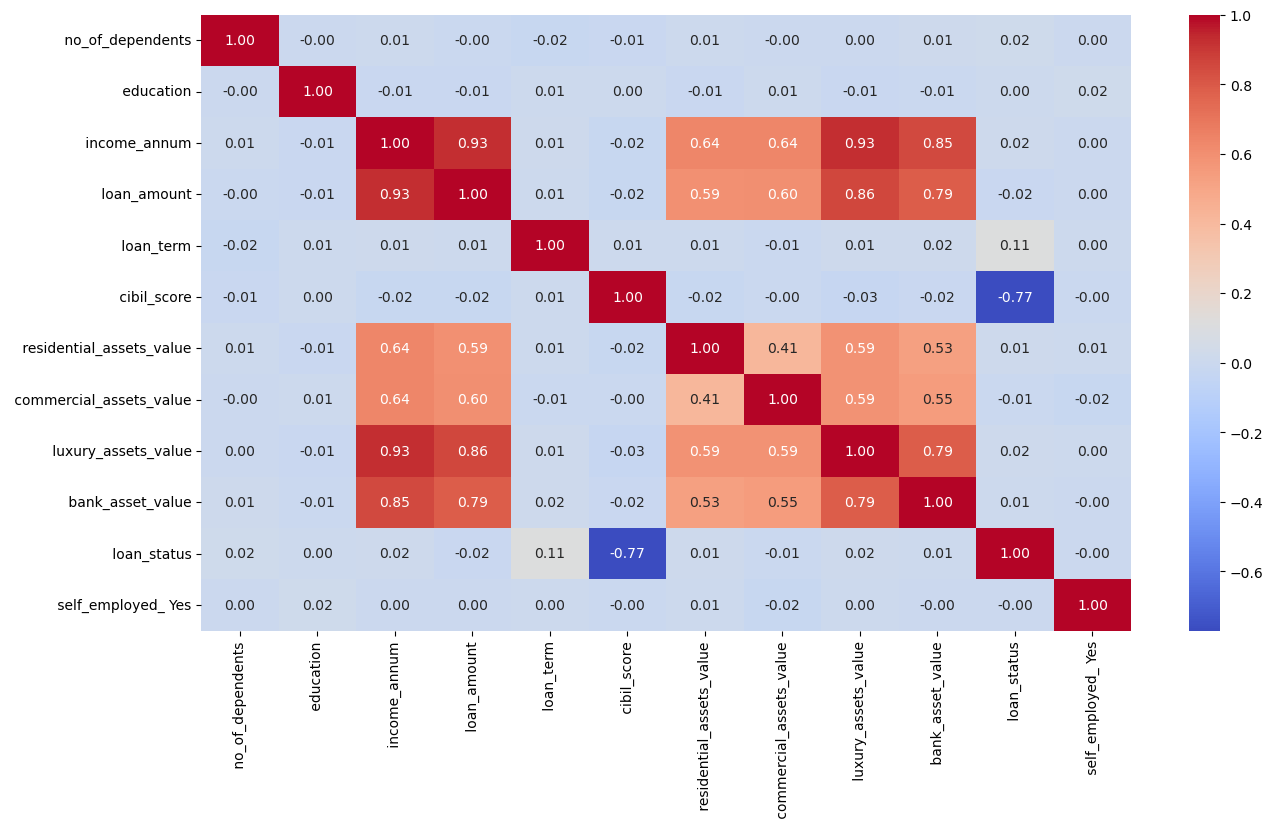

In [20]:
plt.figure(figsize = (15,8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

# Training + Feature scaling

In [21]:
x = df.drop(columns = [" loan_status"])
y = df[" loan_status"]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0    no_of_dependents          4269 non-null   float64
 1    education                 4269 non-null   int64  
 2    income_annum              4269 non-null   float64
 3    loan_amount               4269 non-null   float64
 4    loan_term                 4269 non-null   float64
 5    cibil_score               4269 non-null   float64
 6    residential_assets_value  4269 non-null   float64
 7    commercial_assets_value   4269 non-null   float64
 8    luxury_assets_value       4269 non-null   float64
 9    bank_asset_value          4269 non-null   float64
 10   loan_status               4269 non-null   int64  
 11   self_employed_ Yes        4269 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 400.3 KB


In [22]:
x_train,x_test, y_train,y_test = train_test_split(x,y, test_size=0.2 ,random_state = 40)
ss = StandardScaler()
x_train_scaled = ss.fit_transform(x_train)
x_test_scaled = ss.transform(x_test)

# Train and Evaluate

In [23]:
#logistic_Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score
model = LogisticRegression()
model.fit(x_train_scaled,y_train)
y_pred = model.predict(x_test_scaled)
 # Evaluation
print("precision =",precision_score(y_pred,y_test))
print("recall =",recall_score(y_pred,y_test))
print("f1_score =",f1_score(y_pred,y_test))
print("accuracy =",accuracy_score(y_pred,y_test))
print("cm=",confusion_matrix(y_pred,y_test))
print("report=",classification_report(y_pred,y_test))

precision = 0.8860759493670886
recall = 0.8888888888888888
f1_score = 0.8874801901743264
accuracy = 0.9168618266978923
cm= [[503  36]
 [ 35 280]]
report=               precision    recall  f1-score   support

           0       0.93      0.93      0.93       539
           1       0.89      0.89      0.89       315

    accuracy                           0.92       854
   macro avg       0.91      0.91      0.91       854
weighted avg       0.92      0.92      0.92       854



In [24]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score
KNN_model = KNeighborsClassifier(n_neighbors = 9)
KNN_model.fit(x_train_scaled,y_train)
y_pred = KNN_model.predict(x_test_scaled)
 # Evaluation
print("precision =",precision_score(y_pred,y_test))
print("recall =",recall_score(y_pred,y_test))
print("f1_score =",f1_score(y_pred,y_test))
print("accuracy =",accuracy_score(y_pred,y_test))
print("cm=",confusion_matrix(y_pred,y_test))
print("report=",classification_report(y_pred,y_test))

precision = 0.8829113924050633
recall = 0.8691588785046729
f1_score = 0.8759811616954474
accuracy = 0.9074941451990632
cm= [[496  37]
 [ 42 279]]
report=               precision    recall  f1-score   support

           0       0.92      0.93      0.93       533
           1       0.88      0.87      0.88       321

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.91      0.91      0.91       854



In [25]:
#Naive_bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score
NB_model = GaussianNB()
NB_model.fit(x_train_scaled,y_train)
y_pred = NB_model.predict(x_test_scaled)
 # Evaluation
print("precision =",precision_score(y_pred,y_test))
print("recall =",recall_score(y_pred,y_test))
print("f1_score =",f1_score(y_pred,y_test))
print("accuracy =",accuracy_score(y_pred,y_test))
print("cm=",confusion_matrix(y_pred,y_test))
print("report=",classification_report(y_pred,y_test))

precision = 0.9177215189873418
recall = 0.8868501529051988
f1_score = 0.9020217729393468
accuracy = 0.9262295081967213
cm= [[501  26]
 [ 37 290]]
report=               precision    recall  f1-score   support

           0       0.93      0.95      0.94       527
           1       0.92      0.89      0.90       327

    accuracy                           0.93       854
   macro avg       0.92      0.92      0.92       854
weighted avg       0.93      0.93      0.93       854



In [27]:
df.head(5)

,no_of_dependents,education,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,self_employed_ Yes
0,2.0,0,9600000.0,29900000.0,12.0,778.0,2400000.0,17600000.0,22700000.0,8000000.0,0,0.0
1,0.0,1,4100000.0,12200000.0,8.0,417.0,2700000.0,2200000.0,8800000.0,3300000.0,1,1.0
2,3.0,0,9100000.0,29700000.0,20.0,506.0,7100000.0,4500000.0,33300000.0,12800000.0,1,0.0
3,3.0,0,8200000.0,30700000.0,8.0,467.0,18200000.0,3300000.0,23300000.0,7900000.0,1,0.0
4,5.0,1,9800000.0,24200000.0,20.0,382.0,12400000.0,8200000.0,29400000.0,5000000.0,1,1.0


# best model - Naive Bayes

# feature engineering

In [33]:
df[" loan_term_sq"] = df[" loan_term"] ** 2
df[" cibil_score_sq"] = df[" cibil_score"] ** 2


X = df.drop(columns=[" loan_status", " cibil_score", " loan_term"])
y = df[" loan_status"]

# Train test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [34]:
#logistic_Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score
model = LogisticRegression()
model.fit(x_train_scaled,y_train)
y_pred = model.predict(x_test_scaled)
 # Evaluation
print("precision =",precision_score(y_pred,y_test))
print("recall =",recall_score(y_pred,y_test))
print("f1_score =",f1_score(y_pred,y_test))
print("accuracy =",accuracy_score(y_pred,y_test))
print("cm=",confusion_matrix(y_pred,y_test))
print("report=",classification_report(y_pred,y_test))

precision = 0.9465408805031447
recall = 0.869942196531792
f1_score = 0.9066265060240963
accuracy = 0.927400468384075
cm= [[491  17]
 [ 45 301]]
report=               precision    recall  f1-score   support

           0       0.92      0.97      0.94       508
           1       0.95      0.87      0.91       346

    accuracy                           0.93       854
   macro avg       0.93      0.92      0.92       854
weighted avg       0.93      0.93      0.93       854



In [35]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score
KNN_model = KNeighborsClassifier(n_neighbors = 9)
KNN_model.fit(x_train_scaled,y_train)
y_pred = KNN_model.predict(x_test_scaled)
 # Evaluation
print("precision =",precision_score(y_pred,y_test))
print("recall =",recall_score(y_pred,y_test))
print("f1_score =",f1_score(y_pred,y_test))
print("accuracy =",accuracy_score(y_pred,y_test))
print("cm=",confusion_matrix(y_pred,y_test))
print("report=",classification_report(y_pred,y_test))

precision = 0.8522012578616353
recall = 0.7445054945054945
f1_score = 0.7947214076246334
accuracy = 0.8360655737704918
cm= [[443  47]
 [ 93 271]]
report=               precision    recall  f1-score   support

           0       0.83      0.90      0.86       490
           1       0.85      0.74      0.79       364

    accuracy                           0.84       854
   macro avg       0.84      0.82      0.83       854
weighted avg       0.84      0.84      0.83       854



In [36]:
#Naive_bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score
NB_model = GaussianNB()
NB_model.fit(x_train_scaled,y_train)
y_pred = NB_model.predict(x_test_scaled)
 # Evaluation
print("precision =",precision_score(y_pred,y_test))
print("recall =",recall_score(y_pred,y_test))
print("f1_score =",f1_score(y_pred,y_test))
print("accuracy =",accuracy_score(y_pred,y_test))
print("cm=",confusion_matrix(y_pred,y_test))
print("report=",classification_report(y_pred,y_test))

precision = 0.9968553459119497
recall = 0.7925
f1_score = 0.883008356545961
accuracy = 0.9016393442622951
cm= [[453   1]
 [ 83 317]]
report=               precision    recall  f1-score   support

           0       0.85      1.00      0.92       454
           1       1.00      0.79      0.88       400

    accuracy                           0.90       854
   macro avg       0.92      0.90      0.90       854
weighted avg       0.92      0.90      0.90       854

